<a href="https://colab.research.google.com/github/moeinHP-aussie/image-processing/blob/main/homomorphic_DIP_Ex4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="direction: rtl; line-height: 300%;">
  <font face="XB Zar" size="5">
    <div align="center">
      <font face="IranNastaliq" size="30">
        <p></p>
      </font>
    </div>
    <br>
    <div align="center">
      <font color="brown" size="6">
        معین حسن پور - 40032313
      </font>
    </div>
    <br>
    <div align="center">
      <font color="navy">
        <b><u>تمرین جهارم</u> استفاده از فیلتر همومورفیک</b>
      
 <hr>
  </font>
</div>
 <hr>
  </font>
</div>


<div dir="rtl">
<h2>1- با استفاده از فیلتر همومورفیک مولفه روشنایی و بازتابش دو تصویر زیر را  نمایش دهید.
</div>


<div dir="rtl">

### پارامترهای فیلتر هومومورفیک

| پارامتر      | مقدار پیشفرض | نقش                        | تأثیر                          |
|--------------|--------------|-----------------------------|---------------------------------|
| `gamma_l`    | 0.3          | تضعیف فرکانس‌های پایین (روشنایی)  | ↓ کاهش → سایه‌ها کمتر          |
| `gamma_h`    | 1.5          | تقویت فرکانس‌های بالا (بازتابندگی) | ↑ افزایش → جزئیات واضح‌تر      |
| `c`          | 1            | کنترل شیب انتقال فرکانس‌ها  | ↑ افزایش → مرزهای شارپ‌تر      |
| `d0`         | 30           | فرکانس قطع                | ↑ افزایش → ناحیه تقویت بزرگتر  |


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def homomorphic_filter(image_path, gamma_l=0.3, gamma_h=1.5, c=1, d0=30):
    """
    Apply Homomorphic Filter and display ONLY Illumination & Reflectance components.

    Parameters:
        image_path (str): Path to the input image.
        gamma_l (float): Low-frequency gain (illumination suppression).
        gamma_h (float): High-frequency gain (reflectance enhancement).
        c (float): Controls the sharpness of the filter.
        d0 (int): Cutoff frequency.
    """
    # 1. Read image & convert to grayscale
    img = cv2.imread(image_path, 0)
    if img is None:
        raise ValueError("Image not found or invalid path!")

    # 2. Log transform
    img_log = np.log1p(img.astype(np.float32))

    # 3. Fourier Transform
    dft = np.fft.fft2(img_log)
    dft_shift = np.fft.fftshift(dft)

    # 4. Create Homomorphic filter
    rows, cols = img.shape
    u, v = np.meshgrid(np.arange(cols) - cols//2, np.arange(rows) - rows//2)
    distance = np.sqrt(u**2 + v**2)
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * (distance**2 / (d0**2)))) + gamma_l

    # 5. Apply filter and inverse DFT
    filtered = dft_shift * H
    idft_shift = np.fft.ifftshift(filtered)
    img_filtered = np.fft.ifft2(idft_shift)
    img_filtered = np.real(img_filtered)

    # 6. Exponential to get final result (محاسبه نتیجه برای استفاده در بازتابندگی)
    result = np.expm1(img_filtered)
    result = cv2.normalize(result, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # 7. Extract Illumination and Reflectance
    H_low = 1 - H  # Low-pass filter for illumination
    illumination = np.fft.ifft2(np.fft.ifftshift(dft_shift * H_low)).real
    illumination = np.exp(illumination) - 1
    illumination = cv2.normalize(illumination, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    reflectance = cv2.subtract(result, illumination)

    # 8. Plot ONLY Original, Illumination, Reflectance
    plt.figure(figsize=(15, 5))

    plt.subplot(131), plt.imshow(img, cmap='gray')
    plt.title('Original Image'), plt.axis('off')

    plt.subplot(132), plt.imshow(illumination, cmap='gray')
    plt.title('Illumination (Low Frequency)'), plt.axis('off')

    plt.subplot(133), plt.imshow(reflectance, cmap='gray')
    plt.title('Reflectance (High Frequency)'), plt.axis('off')

    plt.tight_layout()
    plt.show()

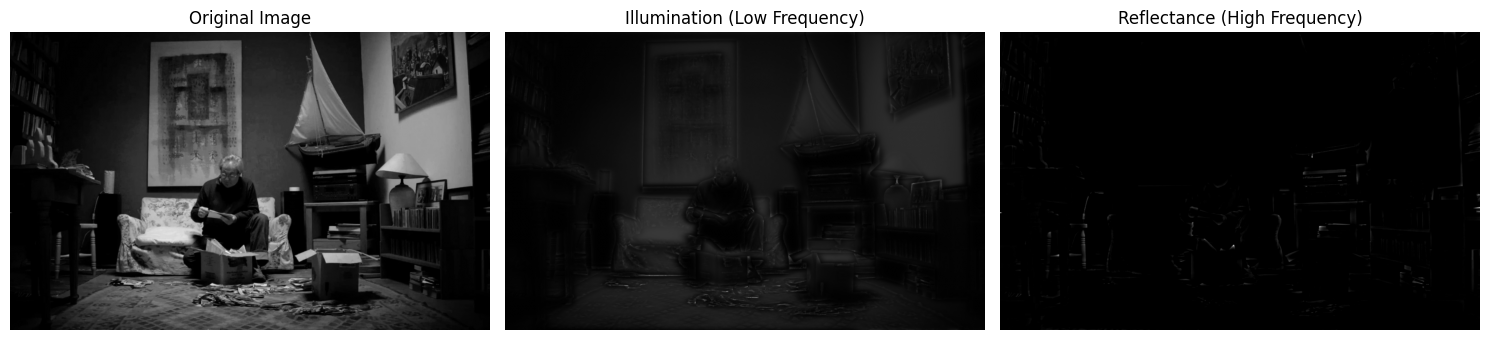

In [ ]:
homomorphic_filter("What_Is_This_Story_and_How_Does_It_End_1.png")

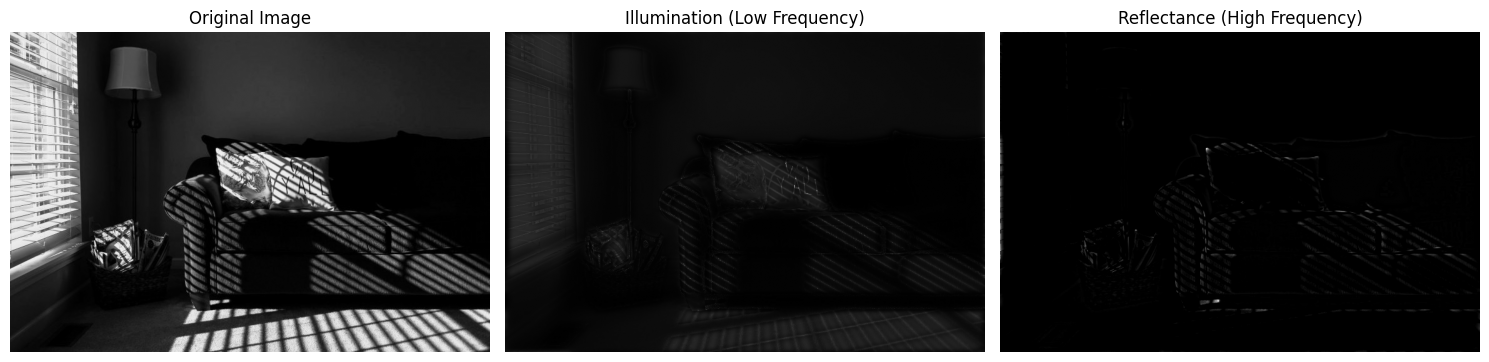

In [ ]:
homomorphic_filter("favorite-photography-spot-home-jonica-weiler-767x512.jpg")

---

<div dir="rtl">
<h2>2- مولفه روشنایی دو تصویر فوق را جابجا کنید و  سپس آن دو تصویر را نشان دهید
</div>


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def homomorphic_components(image_path, target_size=None, gamma_l=0.3, gamma_h=1.5, c=1, d0=30):
    """
    استخراج مولفه‌های روشنایی و بازتابندگی با تغییر اندازه به ابعاد target_size
    """
    # خواندن تصویر و بررسی وجود فایل
    img = cv2.imread(image_path, 0)
    if img is None:
        raise ValueError(f"Image {image_path} not found!")

    # تغییر اندازه تصویر به ابعاد هدف
    if target_size is not None:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # تبدیل لگاریتمی
    img_log = np.log1p(img.astype(np.float32))

    # تبدیل فوریه و جابجایی
    dft = np.fft.fft2(img_log)
    dft_shift = np.fft.fftshift(dft)

    # ساخت فیلتر هومومورفیک
    rows, cols = img.shape
    u, v = np.meshgrid(np.arange(cols) - cols//2, np.arange(rows) - rows//2)
    distance = np.sqrt(u**2 + v**2)
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * (distance**2 / (d0**2)))) + gamma_l

    # استخراج روشنایی (فرکانس پایین)
    H_low = 1 - H
    illumination = np.fft.ifft2(np.fft.ifftshift(dft_shift * H_low)).real
    illumination = np.exp(illumination) - 1
    illumination = cv2.normalize(illumination, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # استخراج بازتابندگی (فرکانس بالا)
    filtered = dft_shift * H
    img_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(filtered)))
    reflectance = np.expm1(img_filtered)
    reflectance = cv2.normalize(reflectance, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    return illumination, reflectance

def swap_illumination(image1_path, image2_path, gamma_l=0.3, gamma_h=1.5, c=1, d0=30):
    """
    تعویض مولفه روشنایی دو تصویر و نمایش نتایج
    """
    # خواندن ابعاد تصاویر
    img1 = cv2.imread(image1_path, 0)
    img2 = cv2.imread(image2_path, 0)

    if img1 is None or img2 is None:
        raise ValueError("One or both images not found!")

    # محاسبه ابعاد کوچکترین تصویر
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    target_size = (min(w1, w2), min(h1, h2))  # (عرض، ارتفاع)

    # استخراج مولفه‌ها با ابعاد یکسان
    illum1, refl1 = homomorphic_components(image1_path, target_size, gamma_l, gamma_h, c, d0)
    illum2, refl2 = homomorphic_components(image2_path, target_size, gamma_l, gamma_h, c, d0)

    # ترکیب مولفه‌ها
    combined_1 = cv2.addWeighted(illum1, 0.5, refl2, 0.5, 0)
    combined_2 = cv2.addWeighted(illum2, 0.5, refl1, 0.5, 0)

    # نمایش نتایج
    plt.figure(figsize=(20, 10))

    # سطر اول: تصویر ۱ و مولفه‌های آن
    plt.subplot(241), plt.imshow(img1, cmap='gray')
    plt.title('Image 1 - Original'), plt.axis('off')

    plt.subplot(242), plt.imshow(illum1, cmap='gray')
    plt.title('Illumination 1'), plt.axis('off')

    plt.subplot(243), plt.imshow(refl1, cmap='gray')
    plt.title('Reflectance 1'), plt.axis('off')

    plt.subplot(244), plt.imshow(combined_1, cmap='gray')
    plt.title('Combined (Illum1 + Refl2)'), plt.axis('off')

    # سطر دوم: تصویر ۲ و مولفه‌های آن
    plt.subplot(245), plt.imshow(img2, cmap='gray')
    plt.title('Image 2 - Original'), plt.axis('off')

    plt.subplot(246), plt.imshow(illum2, cmap='gray')
    plt.title('Illumination 2'), plt.axis('off')

    plt.subplot(247), plt.imshow(refl2, cmap='gray')
    plt.title('Reflectance 2'), plt.axis('off')

    plt.subplot(248), plt.imshow(combined_2, cmap='gray')
    plt.title('Combined (Illum2 + Refl1)'), plt.axis('off')

    plt.tight_layout()
    plt.show()

#

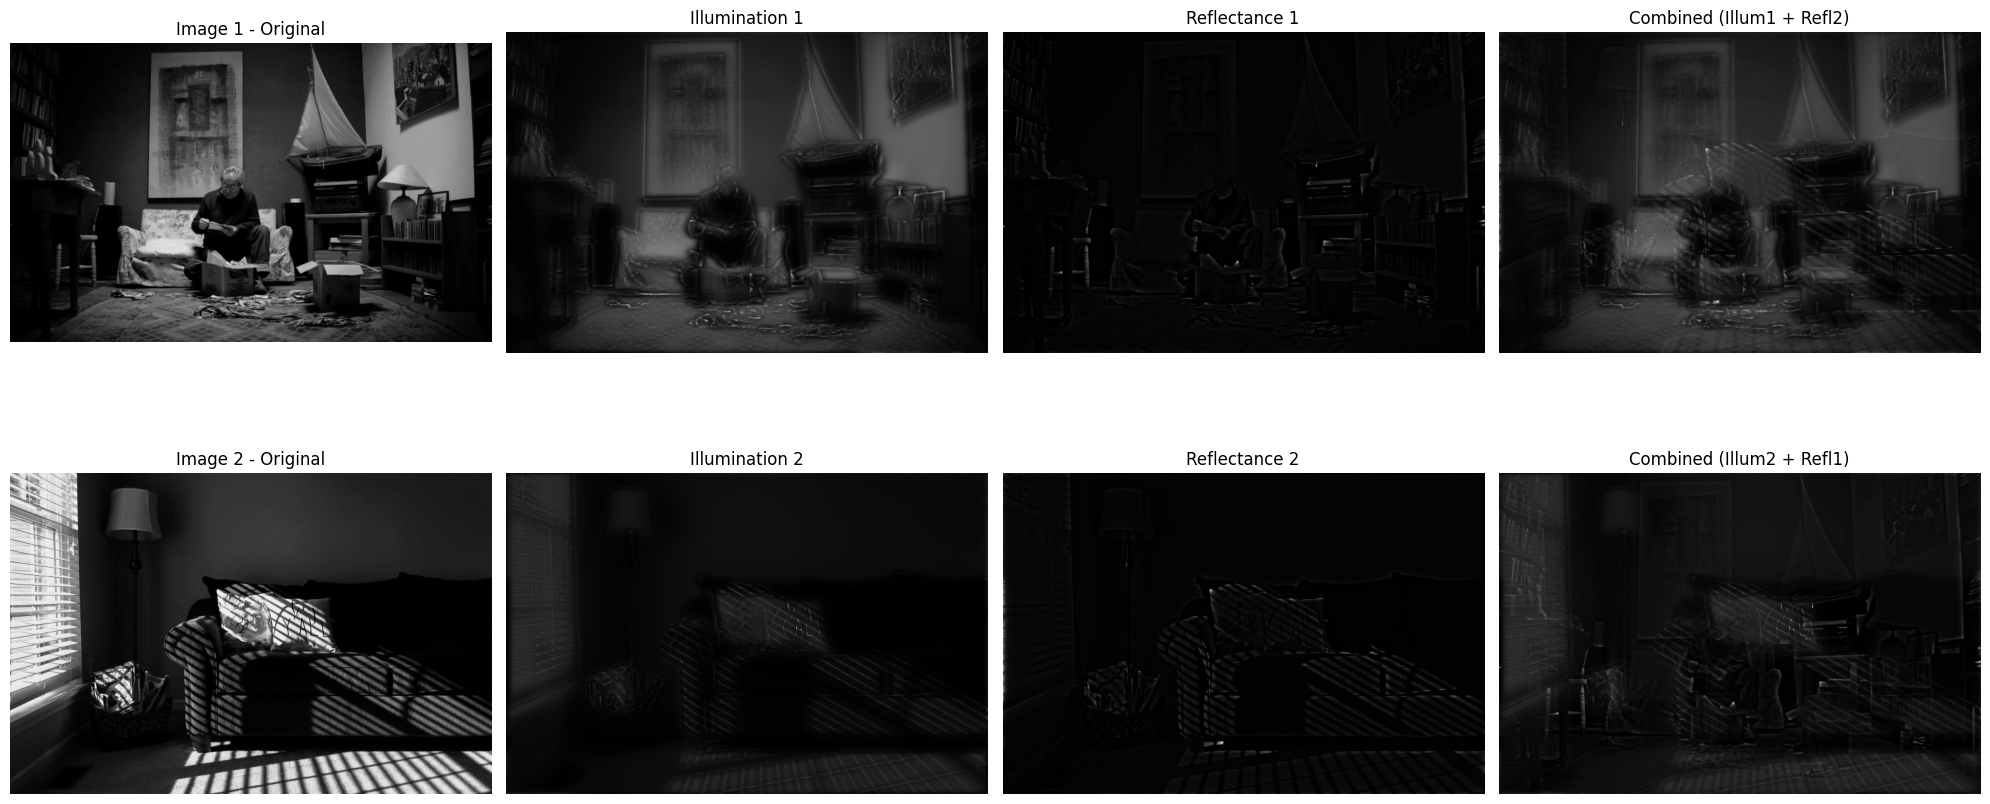

In [ ]:
swap_illumination("What_Is_This_Story_and_How_Does_It_End_1.png","favorite-photography-spot-home-jonica-weiler-767x512.jpg" , gamma_l=0.3, gamma_h=1.5, d0=30)

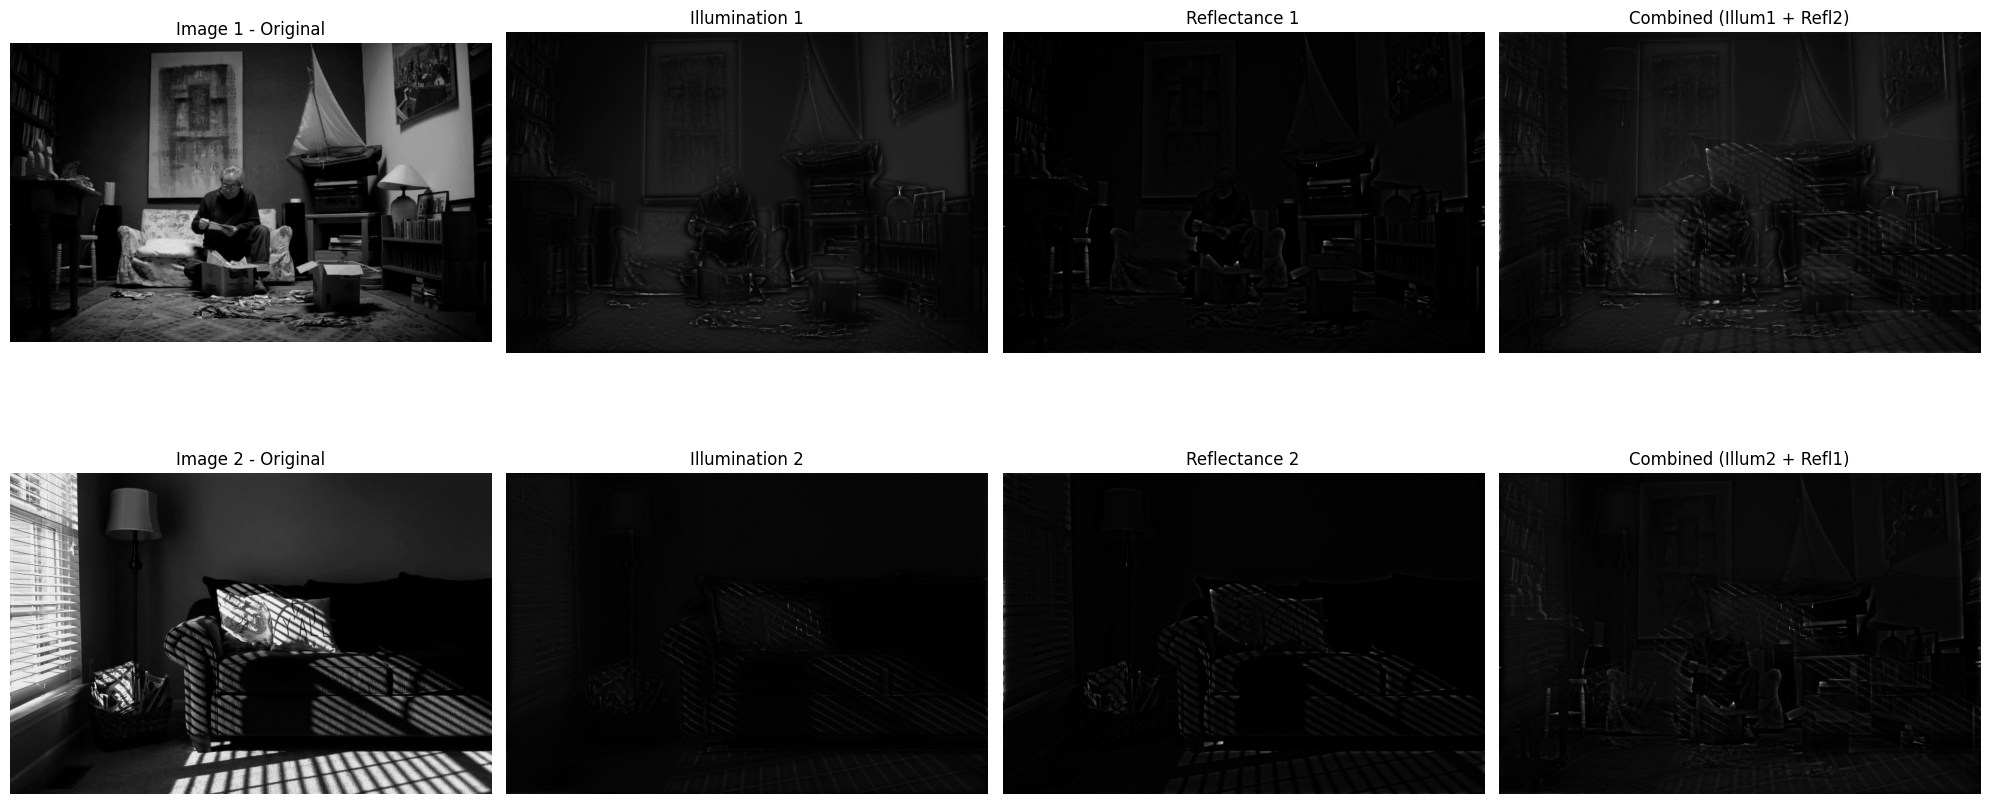

In [ ]:
swap_illumination("What_Is_This_Story_and_How_Does_It_End_1.png","favorite-photography-spot-home-jonica-weiler-767x512.jpg" , gamma_l=0.6, gamma_h=1.7, d0=40)